In [83]:
import argparse
import datetime
import glob
import json
import os
import pdb
import requests
import shutil
import sys
import traceback

from astrocut import fits_cut, img_cut
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.table import Table
from astropy.table import unique
import astropy.wcs as wcs
from astropy.wcs import WCS
from astroquery.mast import Observations

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image, ImageDraw, ImageFont, ImageEnhance
from PIL.PngImagePlugin import PngInfo
from reproject import reproject_interp  # https://reproject.readthedocs.io/en/stable/
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs
from scipy.optimize import golden

from copy import deepcopy
from os.path import join
from os.path import expanduser
home = expanduser("~")

import astropy  # version 4.2 is required to write magnitudes to ecsv file
import astropy.io.fits as pyfits
from astropy.table import QTable
import astropy.units as u
from astropy.visualization import make_lupton_rgb, SqrtStretch, LogStretch, LinearStretch, hist
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import sigma_clipped_stats
import photutils
from importlib import reload




In [84]:
# Trilogy Code
def da(k):
    a1 = k * (x1 - x0) + 1
    a2 = k * (x2 - x0) + 1
    a1n = a1 ** n
    a1n = np.abs(a1n)  # Don't want the solutions where a1 & a2 are both negative!
    da1 = a1n - a2
    k = np.abs(k)
    if k == 0:
        return da(1e-10)
    else:
        da1 = da1 / k  # To avoid solution k = 0!
    return abs(da1)


def imscale2(data, levels, y1):
    # x0, x1, x2  YIELD  0, y1, 1,  RESPECTIVELY
    # y1 = noiselum
    global n, x0, x1, x2  # So that golden can use them
    x0, x1, x2 = levels
    if y1 == 0.5:
        k = (x2 - 2 * x1 + x0) / float(x1 - x0) ** 2
    else:
        n = 1 / y1
        k = np.abs(golden(da))
    r1 = np.log10(k * (x2 - x0) + 1)
    v = np.ravel(data)
    v = clip2(v, 0, None)
    d = k * (v - x0) + 1
    d = clip2(d, 1e-30, None)
    z = np.log10(d) / r1
    z = np.clip(z, 0, 1)
    z.shape = data.shape
    z = z * 255
    z = z.astype(np.uint8)
    return z


def clip2(m, m_min=None, m_max=None):
    # nanmin and nanmax important to ignore nan values
    # otherwise you'll get all 0's
    if m_min == None:
        m_min = np.nanmin(m)
    if m_max == None:
        m_max = np.nanmax(m)
    return np.clip(m, m_min, m_max)


# PREVIOUSLY in colorimage.py
def set_levels(data, pp, stripneg=False, sortedalready=False):
    if sortedalready:
        vs = data
    else:
        print('sorting...')
        vs = np.sort(data.flat)
    if stripneg:  # Get rid of negative values altogether!
        # This is the way I was doing it for a while
        # Now that I'm not, resulting images should change (get lighter)
        i = np.searchsorted(vs, 0)
        vs = vs[i + 1:]
    else:  # Clip negative values to zero
        vs = clip2(vs, 0, None)
    ii = np.array(pp) * len(vs)
    ii = ii.astype(int)
    ii = np.clip(ii, 0, len(vs) - 1)
    levels = vs.take(ii)
    # print ii, levels, vs, sort(vs)
    return levels


def determine_scaling(data, unsatpercent, noisesig=1, correctbias=True, noisefloorsig=2):
    """Determines data values (x0,x1,x2) which will be scaled to (0,noiselum,1)"""
    # Robust mean & standard deviation
    datasorted = data + 0
    datasorted[np.isnan(datasorted)] = 0  # set all nan values to zero
    datasorted = np.sort(datasorted.flat)
    if datasorted[0] == datasorted[-1]:  # data is all one value
        levels = 0, 1, 100  # whatever
    else:
        data_mean, data_median, data_stddev = sigma_clipped_stats(datasorted, mask_value=0)
        m = data_mean
        r = data_stddev
        print('%g +/- %g' % (m, r))

        if correctbias:
            x0 = m - noisefloorsig * r
        else:
            x0 = 0
        x1 = m + noisesig * r
        x2 = set_levels(datasorted, np.array([unsatpercent]), sortedalready=True)[0]
        levels = x0, x1, x2
    return levels


def stamp_extent(data, sample_size=1000, dx=0, dy=0, xc=0, yc=0):
    data_shape = data.shape
    if len(data_shape) == 2:
        ny, nx = data.shape
    else:
        ny, nx, three = data.shape

    if yc:
        dy = 0
    else:
        yc = int(ny / 2)

    if xc:
        dx = 0
    else:
        xc = int(nx / 2)

    ylo = yc - sample_size / 2 + dy
    yhi = yc + sample_size / 2 + dy

    xlo = xc - sample_size / 2 + dx
    xhi = xc + sample_size / 2 + dx

    ylo = int(np.clip(ylo, 0, ny))
    yhi = int(np.clip(yhi, 0, ny))
    xlo = int(np.clip(xlo, 0, nx))
    xhi = int(np.clip(xhi, 0, nx))
    # print(xlo, xhi, ylo, yhi)
    return xlo, xhi, ylo, yhi


# def image_stamps(data, sample_size=1000, dx=0, dy=0, xc=0, yc=0):
# xlo, xhi, ylo, yhi = stamp_extent(data, sample_size, dx, dy)

def image_stamps(data, extent):
    xlo, xhi, ylo, yhi = extent
    stamps = data[ylo:yhi, xlo:xhi]
    return stamps


image_stamp = image_stamps


def roundint(x):
    return int(np.round(x))


def slices_extent(x, y, dx, dy=0):
    dy = dy or dx
    xlo = roundint(x - dx)
    xhi = roundint(x + dx + 1)
    ylo = roundint(y - dy)
    yhi = roundint(y + dy + 1)
    xslice = slice(xlo, xhi)
    yslice = slice(ylo, yhi)
    slices = yslice, xslice
    extent = xlo, xhi, ylo, yhi
    return slices, extent

Filter R G B
f0770w  0.50  0.00  1.00
f1000w  0.17  0.87  0.87
f1130w  0.83  0.87  0.50
f2100w  1.00  0.00  0.00

In [85]:
def determine_pixel_scale(image_file):
    """Access image and return the image WCS information and platescale (arcsec/pixel). Borrowed and adapted
    from https://github.com/spacetelescope/sn_dust/blob/main/colored_images/color_image_generic.ipynb

    Parameters
    ----------
    image_file : str
        image name (with full path)

    Returns
    -------
    imwcs : Astropy.wcs.wcs.WCS object
        The world coordinate system (WCS) information extracted from the input image's header
    image_pixel_scale : float
        The image's pixel scale in arcseconds/pixel
    """
    hdu = fits.open(image_file)
    imwcs = wcs.WCS(hdu[0].header, hdu)
    print(imwcs)
    image_pixel_scale = wcs.utils.proj_plane_pixel_scales(imwcs)[0]
    image_pixel_scale *= imwcs.wcs.cunit[0].to('arcsec')

    return imwcs, image_pixel_scale


In [86]:
def x_rgb(x):
    # -0.25 = purple
    # 0 = blue, 0.5 = green, 1 = red
    xp = -0.25, 0, 0.5, 1
    b_lum = np.interp(x, xp, [1,   1, 0, 0])
    g_lum = np.interp(x, xp, [0,   0, 1, 0])
    r_lum = np.interp(x, xp, [0.5, 0, 0, 1])
    return r_lum, g_lum, b_lum

In [183]:
def make_cutout_image(image_files_dict, target_name, target_ra, target_dec, ref_img_name, instrument_name):
    """Create cutout image and write them to .jpg file

    Parameters
    ----------
    image_files_dict : dict
        dict of image names (with full paths) to process
    target_name : str
        target name
    target_ra : float
        target right ascension, in degrees
    target_dec : float
        target declination, in degrees
    ref_img_name : str
        Name of the reference image.
    instrument_name : str
        JWST instrument name.

    Returns
    -------
    Nothing.
    """
    filters = sorted(image_files_dict.keys())
    print(image_files_dict.keys())
    cmap = plt.colormaps['rainbow']

    # Filter R G B
    # f0770w  0.50  0.00  1.00
    # f1000w  0.17  0.87  0.87
    # f1130w  0.83  0.87  0.50
    # f2100w  1.00  0.00  0.00
    
    filter_colors = {}
    color_info = {}
    for i, filt in enumerate(filters):
        x_min = 0.1  # bluest filter will be purple
        #x_min = 0.1  # bluest filter will be blue
        x = i / (len(filters) - 1) * (1 - x_min) + x_min

        # r_lum, g_lum, b_lum, alpha = cmap(x)
        if filt == 'F0770W':
            r_lum, g_lum, b_lum = 0.5, 0.00, 1.00
        if filt == 'F1000W':
            r_lum, g_lum, b_lum = 0.17, 0.87, 0.87
        if filt == 'F1130W':
            r_lum, g_lum, b_lum = 0.83, 0.87, 0.50
        if filt == 'F2100W':
            r_lum, g_lum, b_lum = 1.0, 0.0, 0.0
        
        rgb_lum = np.array([r_lum, g_lum, b_lum])
        filter_colors[filt] = rgb_lum
        print(filt, ' %4.2f' % r_lum, ' %4.2f' % g_lum, ' %4.2f' % b_lum)
        # padding = " "*(6 - len(filt))
        # foo = "{}{}  {:.2f}  {:.2f}  {:.2f}".format(filt.upper(), padding, r_lum, g_lum, b_lum)
        if filt.upper().endswith("     "):
            color_info[filt.upper()] = "white"
        else:
            color_info[filt.upper()] = (r_lum, g_lum, b_lum)
    filters = filter_colors.keys()
    print(filters)

    for filt in filters:
        filter_colors[filt] = np.array(filter_colors[filt])

    rgb_lum_sum = np.zeros(3)
    for i, filt in enumerate(filters):
        rgb_lum_sum += np.array(filter_colors[filt])

    print('rgb_lum_sum', rgb_lum_sum)

    #REad in all image data
    image_data_dict_rot = {}
    for filt in filters:
        image_file = image_files_dict[filt]
        hdu = fits.open(image_file)
        data = hdu[0].data
        image_data_dict_rot[filt] = data


    # Input parameters
    # Determine size of cutout image in pixels.
    cutout_size_arcsec = 30 # size of cutout in arcseconds

    image_wcs_info, image_pixel_scale = determine_pixel_scale(ref_img_name) # get pixel scale #ref_img_name.replace("_rot.fits", ".fits")
    sample_size = int(cutout_size_arcsec/image_pixel_scale) # convert cutout size from arcsec to pixels

    dx = dy = 0  # don't use offset
    xc, yc = 412.36618, 467.07393

    noiselum = 0.2  # brightness of "the noise". adjusted up from 0.12 to 0.2 to make bracket algorithm work.
    satpercent = 0.01  # percentage of pixels allowed to saturate (e.g., to white)
    unsatpercent = 1 - 0.01 * satpercent

    noisesig = 1  # set e.g., 1-sigma noise to noiselum
    correctbias = True  ## yes because need to dip below 0 by noisefloorsig-sigma
    noisefloorsig = 1  # set black to e.g., 2-sigma below
    # previously noisesigbias

    color_saturation = 2.5#1.5  # increase color saturation > 1

##########


    scaled_images = {}
    levels_all = {}
    for filt in filters:
        data = image_data_dict_rot[filt]
        # data = background_subtracted_dict[filt]
        # print(filt, data.shape)

        position = SkyCoord("{} {}".format(target_ra, target_dec), unit='deg')
        image_file = ref_img_name
        hdu = fits.open(image_file)
        wcs = WCS(hdu[0].header, hdu)

##############################
        if filt == 'F1130W':
            position = SkyCoord("{} {}".format(53.3817083, -36.1486180), unit='deg')
            image_file = image_files_dict[filt]
            hdu = fits.open(image_file)
            wcs = WCS(hdu[0].header, hdu)
            data = image_data_dict_rot[filt]
##############################
        # Use Cutout2d
        cutout = Cutout2D(data, position, (sample_size, sample_size), wcs=wcs, mode='partial', fill_value=0)
        stamp = cutout.data
        wcs_crop = cutout.wcs

        levels = determine_scaling(stamp.ravel(), unsatpercent, noisesig, correctbias, noisefloorsig)
        scaled = imscale2(stamp, levels, noiselum)
        levels_all[filt] = levels
        scaled_images[filt] = scaled

    rgb_total = 0
    for filt in filters:
        rgb = r, g, b = filter_colors[filt][:, np.newaxis, np.newaxis] * scaled_images[filt]
        # imrgb = np.array([r, g, b]).transpose((1,2,0)).astype(np.uint8)
        rgb_total = rgb_total + rgb

    r, g, b = rgb_average = rgb_total / rgb_lum_sum[:, np.newaxis, np.newaxis]

    imrgb = np.array([r, g, b]).transpose((1, 2, 0)).astype(np.uint8)


    # fig, ax = plt.subplots(1, 1, figsize=(9.5, 6))
    # plt.imshow(imrgb, origin='lower', extent=my_stamp_extent)  # (xlo,xhi,ylo,yhi))
    #
    im = Image.fromarray(imrgb, 'RGB')
    im = im.transpose(method=Image.Transpose.FLIP_TOP_BOTTOM)
    if color_saturation > 1:
        im = ImageEnhance.Color(im).enhance(color_saturation)
    # im.show()

    color_image = np.asarray(im)[::-1]

    fig = plt.figure(figsize=(9.5, 6))
    ax = fig.add_subplot(1, 1, 1, projection=wcs_crop)  # , sharex=True, sharey=True)
    plt.imshow(color_image, origin='lower', interpolation='none')
    plt.gca().invert_xaxis()
    plt.xlabel('Right Ascension')
    plt.ylabel('Declination')
    ax.tick_params(axis='both', direction='in', color='white')
    plt.title("{} ({})".format(target_name,instrument_name.upper()))
    ax.set_autoscale_on(False)  # freeze all motor functions

    # x, y = 10 + (sample_size/2), (sample_size/2) - 3
    # dx, dy = 20, 0
    x, y = (sample_size/2), (sample_size/2)
    dx, dy = 20, 0
    ax.arrow(x - dx + 12, y+1, -dx, dy, head_width=0, head_length=0, lw=1.0, fc='white', ec='white') # Horizontal line
    ax.arrow(x , y + 7, -dy, dx, head_width=0, head_length=0, lw=1.0, fc='white', ec='white') # Vertical line
    
    # plt.tight_layout()
    # plt.show()  # wait a few seconds for update to show up above
    # safe cutout to .jpg file

    for filter_ctr, filter in zip(range(0, len(color_info.keys())), reversed(sorted(color_info.keys()))):
        if filter_ctr == 0:
            text = ax.text(sample_size-2, 3, filter, color=color_info[filter])#, bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 0})
        else:
            text = ax.annotate(filter, xycoords=text, xy=(0, 1), verticalalignment="bottom", color=color_info[filter])

    cutout_image_filename = os.path.join(os.getcwd(), '{}_color.jpg'.format(target_name))

    plt.savefig('/Users/sophiakressy/Desktop/1983vcr_cutout.pdf',bbox_inches='tight', dpi=800)
    # plt.savefig('{}'.format(cutout_image_filename), bbox_inches='tight', dpi=800)
    # print("Wrote {}".format( cutout_image_filename))


In [184]:
# npath = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/'
# miri_north_files = [npath+'North_f770w.fits',npath+'North_f1000w.fits',npath+'North_f1130w.fits',npath+"North_f2100w.fits"]

image_files_dict = {'F0770W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f770w.fits',
                    'F1000W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f1000w.fits',
                    'F1130W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f1130w.fits',
                    'F2100W':'/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f2100w.fits'}
target_name = 'SN1983V'
target_ra = 53.3817329 # 53.3817083
target_dec = -36.1486728 # -36.1486180
ref_img_name = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V/north_oriented/North_f770w.fits'
instrument_name = 'MIRI'

# image_files_dict = {'F0770W':'/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/jw04225-o001_t001_miri_f770w_jhat.fits',
#                     'F1000W':'/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/jw04225-o001_t001_miri_f1000w_jhat.fits',
#                     'F1130W':'/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/jw04225-o001_t001_miri_f1130w_jhat.fits'}
# target_name = 'SN1996cr'
# target_ra = 213.2917505 
# target_dec = -65.3457024
# ref_img_name = '/Users/sophiakressy/Desktop/Snazzy_AR_Proposal_figure/1996cr_jhatted/jw04225-o001_t001_miri_f770w_jhat.fits'
# instrument_name = 'MIRI'



dict_keys(['F0770W', 'F1000W', 'F1130W', 'F2100W'])
F0770W  0.50  0.00  1.00
F1000W  0.17  0.87  0.87
F1130W  0.83  0.87  0.50
F2100W  1.00  0.00  0.00
dict_keys(['F0770W', 'F1000W', 'F1130W', 'F2100W'])
rgb_lum_sum [2.5  1.74 2.37]
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.379789290286 -36.187893752187 
CRPIX : 4805.0 2777.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 3.0811802513623e-05 3.0811802513623e-05 
NAXIS : 9610  5554
0.735923 +/- 0.768878
0.196096 +/- 0.238109
1.07004 +/- 1.1406
0.119474 +/- 0.187513


Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.445674 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645677817.028 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


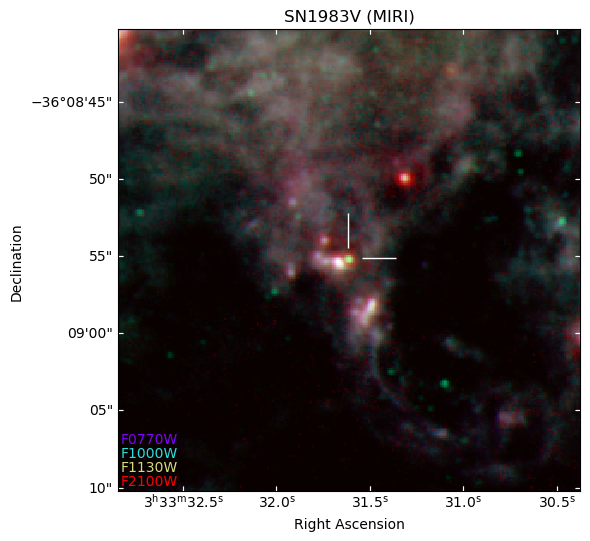

In [185]:
make_cutout_image(image_files_dict, target_name, target_ra, target_dec, ref_img_name, instrument_name)

    # f0770w  0.50  0.00  1.00
    # f1000w  0.17  0.87  0.87
    # f1130w  0.83  0.87  0.50
    # f2100w  1.00  0.00  0.00